In [10]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn', 'matplotlib'])

CompletedProcess(args=['pip', 'install', 'seaborn', 'matplotlib'], returncode=0)

In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_excel('../data/Forecasting Case- Study.xlsx')

In [13]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Data:")
df.head(10)

Shape: (8084, 4)

Columns: ['State', 'Date', 'Total', 'Category']

Data Types:
 State           str
Date         object
Total       float64
Category        str
dtype: object

Missing Values:
 State       0
Date        0
Total       0
Category    0
dtype: int64

Sample Data:


,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages
5,Connecticut,2019-01-12 00:00:00,49715400.0,Beverages
6,Florida,2019-01-12 00:00:00,358112985.7,Beverages
7,Georgia,2019-01-12 00:00:00,198967926.5,Beverages
8,Illinois,2019-01-12 00:00:00,167913696.8,Beverages
9,Indiana,2019-01-12 00:00:00,117489218.5,Beverages


# Data Cleaning & EDA

In [14]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['State', 'Date']).reset_index(drop=True)

print("Date Range:", df['Date'].min(), "to", df['Date'].max())
print("Total States:", df['State'].nunique())
print("States:", sorted(df['State'].unique()))
print("Unique Dates per State:", df.groupby('State')['Date'].count().unique())
print("Category:", df['Category'].unique())

Date Range: 2019-01-12 00:00:00 to 2023-12-03 00:00:00
Total States: 43
States: ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
Unique Dates per State: [188]
Category: <StringArray>
['Beverages']
Length: 1, dtype: str


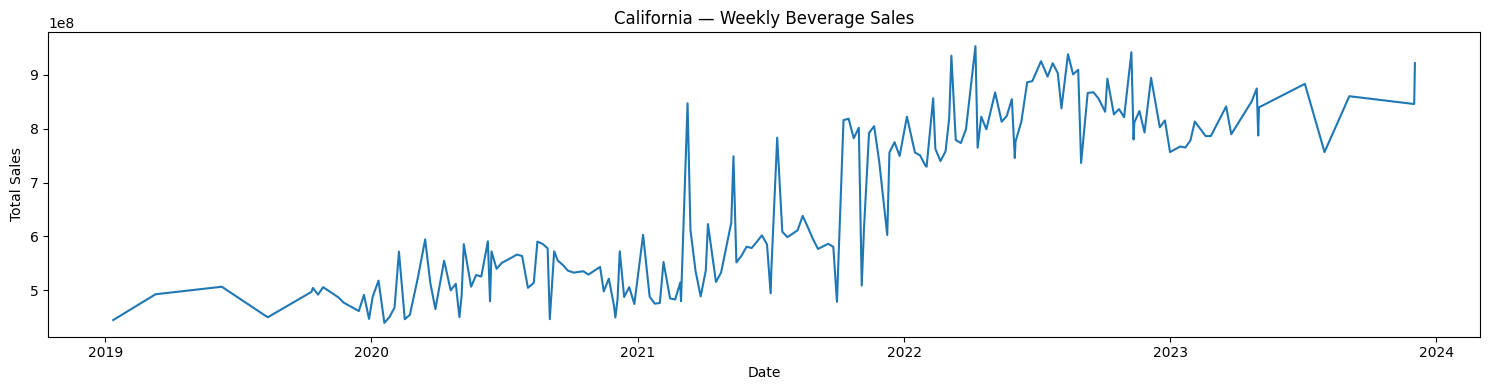


Top 5 States by Total Sales:
State
Texas         1.290921e+11
California    1.240391e+11
Florida       1.020484e+11
New York      6.282658e+10
Georgia       5.504005e+10
Name: Total, dtype: float64


In [15]:
# Section 3 — EDA Visualization
sample_state = 'California'
state_df = df[df['State'] == sample_state].copy()

plt.figure(figsize=(15, 4))
plt.plot(state_df['Date'], state_df['Total'])
plt.title(f'{sample_state} — Weekly Beverage Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Top 5 states by total sales
top5 = df.groupby('State')['Total'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 States by Total Sales:")
print(top5)

# Section 4 — Feature Engineering

In [16]:

import holidays
def create_features(df):
    df = df.copy()
    
    # US Holidays
    us_holidays = holidays.US(years=range(2019, 2025))
    
    # Date features
    df['week'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['year'] = df['Date'].dt.year
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['is_holiday'] = df['Date'].dt.date.apply(
        lambda x: 1 if x in us_holidays else 0
    )
    
    # Lag features per state
    df = df.sort_values(['State', 'Date'])
    df['lag_1'] = df.groupby('State')['Total'].shift(1)   # 1 week pehle
    df['lag_4'] = df.groupby('State')['Total'].shift(4)   # 1 month pehle
    df['lag_8'] = df.groupby('State')['Total'].shift(8)   # 2 months pehle
    
    # Rolling features per state
    df['rolling_mean_4'] = df.groupby('State')['Total'].transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
    df['rolling_std_4'] = df.groupby('State')['Total'].transform(
        lambda x: x.shift(1).rolling(4).std()
    )
    df['rolling_mean_8'] = df.groupby('State')['Total'].transform(
        lambda x: x.shift(1).rolling(8).mean()
    )
    
    # If Missing values then drop it
    df = df.dropna().reset_index(drop=True)
    return df

df_featured = create_features(df)

print("Shape after feature engineering:", df_featured.shape)
print("\nNew columns:", df_featured.columns.tolist())
print("\nSample:")
df_featured.head(3)

Shape after feature engineering: (7740, 16)

New columns: ['State', 'Date', 'Total', 'Category', 'week', 'month', 'quarter', 'year', 'dayofweek', 'is_holiday', 'lag_1', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8']

Sample:


,State,Date,Total,Category,week,month,quarter,year,dayofweek,is_holiday,lag_1,lag_4,lag_8,rolling_mean_4,rolling_std_4,rolling_mean_8
0,Alabama,2019-11-17,109056410.0,Beverages,46,11,4,2019,6,0,109968010.6,110932912.8,109574036.0,1.152255e+08,6.331744e+06,1.149820e+08
1,Alabama,2019-11-24,113040422.1,Beverages,47,11,4,2019,6,0,109056410.0,123782285.8,112189103.8,1.147564e+08,6.807449e+06,1.149173e+08
2,Alabama,2019-12-15,108528456.4,Beverages,50,12,4,2019,6,0,113040422.1,116218908.9,129106730.4,1.120709e+08,3.248345e+06,1.150237e+08


In [17]:
# Section 5 — Train/Test Split (Fixed)

# Unique dates lo, last 8 unique dates = test
unique_dates = sorted(df_featured['Date'].unique())
cutoff_date = unique_dates[-9]  # last 8 dates test mein jayengi

train = df_featured[df_featured['Date'] <= cutoff_date].copy()
test = df_featured[df_featured['Date'] > cutoff_date].copy()

print("Train size:", train.shape)
print("Test size:", test.shape)
print("\nTrain date range:", train['Date'].min(), "to", train['Date'].max())
print("Test date range:", test['Date'].min(), "to", test['Date'].max())
print("\nTest unique dates:", sorted(test['Date'].unique()))
print("Test mein kitne unique dates:", test['Date'].nunique())

Train size: (7396, 16)
Test size: (344, 16)

Train date range: 2019-11-17 00:00:00 to 2023-04-23 00:00:00
Test date range: 2023-04-30 00:00:00 to 2023-12-03 00:00:00

Test unique dates: [Timestamp('2023-04-30 00:00:00'), Timestamp('2023-05-02 00:00:00'), Timestamp('2023-05-03 00:00:00'), Timestamp('2023-07-05 00:00:00'), Timestamp('2023-08-01 00:00:00'), Timestamp('2023-09-04 00:00:00'), Timestamp('2023-12-02 00:00:00'), Timestamp('2023-12-03 00:00:00')]
Test mein kitne unique dates: 8


# ARIMA Model

In [18]:
# Section 6 — ARIMA Model
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

arima_results = {}

states = df_featured['State'].unique()

for state in states:
    try:
        # State ka data lo
        state_train = train[train['State'] == state][['Date', 'Total']].set_index('Date')
        state_test = test[test['State'] == state][['Date', 'Total']].set_index('Date')
        
        # ARIMA model train karo
        model = ARIMA(state_train['Total'], order=(1, 1, 1))
        fitted = model.fit()
        
        # Predict karo
        forecast = fitted.forecast(steps=len(state_test))
        
        # Error calculate karo
        mae = mean_absolute_error(state_test['Total'], forecast)
        rmse = np.sqrt(mean_squared_error(state_test['Total'], forecast))
        
        arima_results[state] = {
            'mae': mae,
            'rmse': rmse,
            'forecast': forecast.values
        }
    except Exception as e:
        print(f"Error in {state}: {e}")

# Summary
arima_mae = np.mean([v['mae'] for v in arima_results.values()])
arima_rmse = np.mean([v['rmse'] for v in arima_results.values()])

print(f"ARIMA — Average MAE: {arima_mae:,.2f}")
print(f"ARIMA — Average RMSE: {arima_rmse:,.2f}")
print(f"States successfully trained: {len(arima_results)}/43")

ARIMA — Average MAE: 11,477,888.12
ARIMA — Average RMSE: 13,158,763.95
States successfully trained: 43/43


# Prophet model

In [20]:
# Section 7 — Prophet Model
from prophet import Prophet
prophet_results = {}
for state in states:
    try:
        # Prophet ko ds aur y columns chahiye
        state_train = train[train['State'] == state][['Date', 'Total']].copy()
        state_train.columns = ['ds', 'y']
        
        state_test = test[test['State'] == state][['Date', 'Total']].copy()
        state_test.columns = ['ds', 'y']

        # Model training
        model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model.fit(state_train)

        # Prediction
        future = model.make_future_dataframe(periods=len(state_test), freq='W')
        forecast = model.predict(future)
        predicted = forecast['yhat'].tail(len(state_test)).values

        # Error calculation
        mae = mean_absolute_error(state_test['y'], predicted)
        rmse = np.sqrt(mean_squared_error(state_test['y'], predicted))

        prophet_results[state] = {
            'mae': mae,
            'rmse': rmse,
            'forecast': predicted
        }

    except Exception as e:
        print(f"Error in {state}: {e}")

# Summary
prophet_mae = np.mean([v['mae'] for v in prophet_results.values()])
prophet_rmse = np.mean([v['rmse'] for v in prophet_results.values()])

print(f"Prophet — Average MAE: {prophet_mae:,.2f}")
print(f"Prophet — Average RMSE: {prophet_rmse:,.2f}")
print(f"States successfully trained: {len(prophet_results)}/43")

15:41:00 - cmdstanpy - INFO - Chain [1] start processing
15:41:00 - cmdstanpy - INFO - Chain [1] done processing
15:41:00 - cmdstanpy - INFO - Chain [1] start processing
15:41:00 - cmdstanpy - INFO - Chain [1] done processing
15:41:01 - cmdstanpy - INFO - Chain [1] start processing
15:41:01 - cmdstanpy - INFO - Chain [1] done processing
15:41:01 - cmdstanpy - INFO - Chain [1] start processing
15:41:01 - cmdstanpy - INFO - Chain [1] done processing
15:41:02 - cmdstanpy - INFO - Chain [1] start processing
15:41:02 - cmdstanpy - INFO - Chain [1] done processing
15:41:02 - cmdstanpy - INFO - Chain [1] start processing
15:41:02 - cmdstanpy - INFO - Chain [1] done processing
15:41:03 - cmdstanpy - INFO - Chain [1] start processing
15:41:03 - cmdstanpy - INFO - Chain [1] done processing
15:41:03 - cmdstanpy - INFO - Chain [1] start processing
15:41:03 - cmdstanpy - INFO - Chain [1] done processing
15:41:04 - cmdstanpy - INFO - Chain [1] start processing
15:41:04 - cmdstanpy - INFO - Chain [1]

Prophet — Average MAE: 13,983,471.70
Prophet — Average RMSE: 17,494,146.89
States successfully trained: 43/43


# XGBoost Model

In [21]:
# Section 8 — XGBoost Model
from xgboost import XGBRegressor
# Feature columns jo XGBoost use karega
feature_cols = ['week', 'month', 'quarter', 'year', 'dayofweek', 
                'is_holiday', 'lag_1', 'lag_4', 'lag_8', 
                'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8']

xgb_results = {}

for state in states:
    try:
        state_train = train[train['State'] == state].copy()
        state_test = test[test['State'] == state].copy()

        X_train = state_train[feature_cols]
        y_train = state_train['Total']
        X_test = state_test[feature_cols]
        y_test = state_test['Total']

        # Model train 
        model = XGBRegressor(n_estimators=100, learning_rate=0.1, 
                             max_depth=4, random_state=42, verbosity=0)
        model.fit(X_train, y_train)

        # Predict calculation
        predicted = model.predict(X_test)

        # Error calculation
        mae = mean_absolute_error(y_test, predicted)
        rmse = np.sqrt(mean_squared_error(y_test, predicted))

        xgb_results[state] = {
            'mae': mae,
            'rmse': rmse,
            'forecast': predicted,
            'model': model
        }

    except Exception as e:
        print(f"Error in {state}: {e}")

# Summary
xgb_mae = np.mean([v['mae'] for v in xgb_results.values()])
xgb_rmse = np.mean([v['rmse'] for v in xgb_results.values()])

print(f"XGBoost — Average MAE: {xgb_mae:,.2f}")
print(f"XGBoost — Average RMSE: {xgb_rmse:,.2f}")
print(f"States successfully trained: {len(xgb_results)}/43")

XGBoost — Average MAE: 10,935,476.56
XGBoost — Average RMSE: 13,225,062.61
States successfully trained: 43/43


# LSTM Model

In [22]:
import subprocess
subprocess.run(['pip', 'install', 'torch', '--index-url', 'https://download.pytorch.org/whl/cpu'])

CompletedProcess(args=['pip', 'install', 'torch', '--index-url', 'https://download.pytorch.org/whl/cpu'], returncode=0)

In [23]:
# Section 9 — LSTM Model

from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

states = df_featured['State'].unique()  

# LSTM Architecture
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def create_sequences(data, seq_len=8):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

lstm_results = {}
SEQ_LEN = 8

for state in states:
    try:
        state_data = df_featured[df_featured['State'] == state][['Date','Total']].copy()
        state_data = state_data.sort_values('Date')

        values = state_data['Total'].values.reshape(-1, 1)

        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(values)

        train_size = len(scaled) - 8
        train_seq = scaled[:train_size]
        test_actual = values[train_size:]

        X, y = create_sequences(train_seq, SEQ_LEN)
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.FloatTensor(y)

        model = LSTMModel()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        criterion = nn.MSELoss()

        model.train()
        for epoch in range(50):
            optimizer.zero_grad()
            output = model(X_tensor)
            loss = criterion(output, y_tensor)
            loss.backward()
            optimizer.step()

        model.eval()
        predictions = []
        input_seq = torch.FloatTensor(scaled[train_size-SEQ_LEN:train_size]).unsqueeze(0)

        with torch.no_grad():
            for _ in range(8):
                pred = model(input_seq)
                predictions.append(pred.item())
                input_seq = torch.cat([input_seq[:, 1:, :], pred.unsqueeze(0)], dim=1)

        predicted = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

        mae = mean_absolute_error(test_actual, predicted)
        rmse = np.sqrt(mean_squared_error(test_actual, predicted))

        lstm_results[state] = {
            'mae': mae,
            'rmse': rmse,
            'forecast': predicted
        }

    except Exception as e:
        print(f"Error in {state}: {e}")

lstm_mae = np.mean([v['mae'] for v in lstm_results.values()])
lstm_rmse = np.mean([v['rmse'] for v in lstm_results.values()])

print(f"LSTM — Average MAE: {lstm_mae:,.2f}")
print(f"LSTM — Average RMSE: {lstm_rmse:,.2f}")
print(f"States successfully trained: {len(lstm_results)}/43")

LSTM — Average MAE: 11,750,329.47
LSTM — Average RMSE: 13,447,228.51
States successfully trained: 43/43


# Model Comparison + Best Model Save

In [24]:
# Section 10 — Model Comparison + Best Model Save

import joblib

# Comparison table
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost', 'LSTM'],
    'MAE': [arima_mae, prophet_mae, xgb_mae, lstm_mae],
    'RMSE': [arima_rmse, prophet_rmse, xgb_rmse, lstm_rmse]
})

comparison = comparison.sort_values('MAE').reset_index(drop=True)
comparison['Rank'] = comparison.index + 1
print("Model Comparison:")
print(comparison.to_string(index=False))

# Best model — XGBoost
print("\nBest Model: XGBoost (Lowest MAE)")

# Save karo — har state ka model
import os
os.makedirs('../models', exist_ok=True)

for state, result in xgb_results.items():
    filename = f"../models/xgb_{state.replace(' ', '_')}.pkl"
    joblib.dump(result['model'], filename)

print(f"\nSaved {len(xgb_results)} XGBoost models in /models folder")

# Feature columns save karo API ke liye
joblib.dump(feature_cols, '../models/feature_cols.pkl')
print(" Feature columns saved")

Model Comparison:
  Model          MAE         RMSE  Rank
XGBoost 1.093548e+07 1.322506e+07     1
  ARIMA 1.147789e+07 1.315876e+07     2
   LSTM 1.175033e+07 1.344723e+07     3
Prophet 1.398347e+07 1.749415e+07     4

Best Model: XGBoost (Lowest MAE)

Saved 43 XGBoost models in /models folder
 Feature columns saved


# Visualization

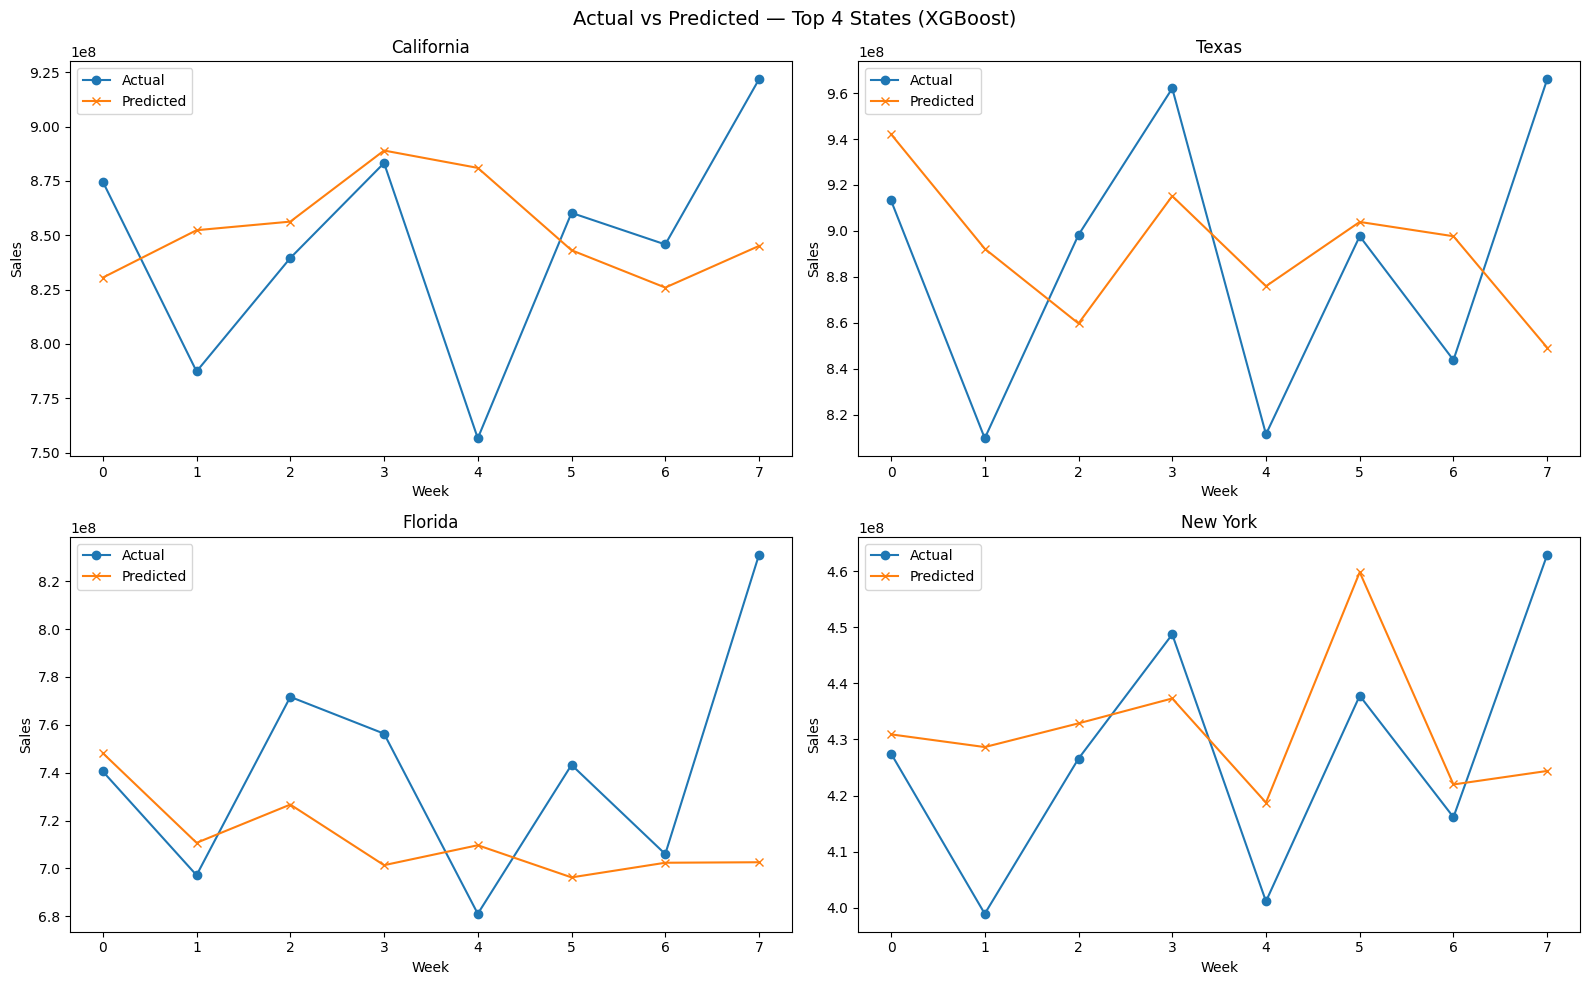

Visualization complete!


In [25]:
# Section 11 — Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Actual vs Predicted — Top 4 States (XGBoost)', fontsize=14)

top_states = ['California', 'Texas', 'Florida', 'New York']

for idx, state in enumerate(top_states):
    ax = axes[idx//2][idx%2]
    
    state_test = test[test['State'] == state]
    actual = state_test['Total'].values
    predicted = xgb_results[state]['forecast']
    
    ax.plot(actual, label='Actual', marker='o')
    ax.plot(predicted, label='Predicted', marker='x')
    ax.set_title(state)
    ax.legend()
    ax.set_xlabel('Week')
    ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()
print("Visualization complete!")